# NicheNet training: case-control study example

In this case study, we will use mouse NICHE-seq data from Medaglia et al. (2017) to explore intercellular communication in the T cell area in the inguinal lymph node before and 72 hours after lymphocytic choriomeningitis virus (LCMV) infection. Specifically, we will prioritize which ligands can best explain the downstream changes after LCMV infection in CD8 T cells as the receiver population. This dataset contains 13,541 genes and 5,027 cells from 6 cell populations: CD4 T cells (including regulatory T cells), CD8 T cells, B cells, NK cells, dendritic cells (DCs) and inflammatory monocytes.

The ligand-target prior model is a matrix describing the potential that a ligand may regulate a target gene, and it is used to run the ligand activity analysis. The ligand-receptor network contains information on potential ligand-receptor bindings, and it is used to identify potential ligands. Finally, the weighted ligand-receptor network contains weights representing the potential that a ligand will bind to a receptor, and it is used for visualization.

These networks were translated from human to mouse gene names using one-to-one orthologs when feasible, and one-to-many conversion was allowed when necessary (for instance, when one human gene symbol corresponded to two mouse gene symbols). Users that are interested in building prior models for other organisms can either create an organism-specific model using data sources relevant to that organism, or use the existing human NicheNet model to convert human gene symbols to their corresponding one-to-one orthologs in the organism of interest. However, this decision depends on one hand, the availability of data for the organism of interest and on the other, the homology between humans and the organism of interest. For instance, using the human model and converting gene symbols might work for primates, but creating a new model from species-specific data sources is better suited for organisms like Drosophila.

<img src="./images/protocols/figure2.png" style="width:70.0%" />

In [ ]:
from nichenetpy.utils import (
    combine_by_key,
    combine_dicts,
    subset_matrix
)
from nichenetpy.extraction import (
    get_expressed_genes,
    subset_ann,
    get_weighted_ligand_receptor_links,
    get_lfc_celltype
)
from nichenetpy.gene_symbol import mouse_alias_info
from nichenetpy.visualization import (
    prepare_ligand_target_visualization,
    prepare_ligand_receptor_visualization,
    heatmap_2d,
    heatmap_1d,
    assign_ligands_to_celltype,
    get_ligand_signaling_path,
    visualize_ligand_signaling_graph
)
from nichenetpy.metrics import group_metrics
from nichenetpy.wrappers import (
    create_ligand_links_circos_plot,
    generate_info_tables
)
from nichenetpy.prioritization import (
    generate_prioritization_table,
    process_table_to_ic,
    calculate_de,
    get_avg_exp
)

from itertools import cycle, chain

import anndata
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import os
import requests
import pickle
import pandas as pd

Download the model files

In [2]:
filename = "nichenet_mouse.pkl"
file_path = os.path.join("./tutorial_files", filename)
if not os.path.exists(file_path):
    res = requests.get(f"https://zenodo.org/records/14887637/files/{filename}")
    with open(file_path, "wb") as file:
        file.write(res.content)

Download the AnnData object

In [3]:
data_path = os.path.normpath("./tutorial_files/AnnData")
if not os.path.exists(data_path):
    os.makedirs(data_path)
filename = "annData3531889.h5"
file_path = os.path.join(data_path, filename)
if not os.path.exists(file_path):
    res = requests.get(f"https://zenodo.org/records/14859451/files/{filename}")
    with open(file_path, "wb") as file:
        file.write(res.content)

### Feature extraction

1) Read in the model networks

In [4]:
with open("./tutorial_files/nichenet_mouse.pkl", "rb") as file:
    model = pickle.loads(file.read())
predictor = model["predictor"]
lr_network = model["lr_network"]
lr_sig = model["lr_sig"]
gr = model["gr"]

2) Read in the AnnData object

In [5]:
ann = anndata.io.read_h5ad(os.path.join(data_path, "annData3531889.h5"))
ann.var_names = ann.var["gene"]
ann

AnnData object with n_obs × n_vars = 5027 × 13541
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nGene', 'nUMI', 'aggregate', 'res.0.6', 'celltype'
    var: 'gene'
    layers: 'counts', 'data', 'scale.data'

3) For expression data with older gene symbols, convert them to more recent gene symbols. 

In [6]:
mouse_alias_info.alias_to_symbol(ann)

4) Define a "receiver" cell population. The receiver cell population can only consist of one cell type.

In [7]:
receiver = "CD8 T" 

5) Determine which genes are expressed in the receiver cell population. The function get_expressed_genes considers genes to be expressed if they have non-zero counts in a certain percentage of the cell population (by default set at 10%). Here, we have lowered the threshold to 5% (pct) as some of the ligands and receptors are very lowly expressed. Users are also free to define expressed genes differently in a way that fits their data.

In [8]:
expressed_genes_receiver = set(get_expressed_genes(receiver, ann, 0.05))

6) Get a list of all receptors available in the ligand-receptor network, and define expressed receptors as genes that are in the ligand-receptor network and expressed in the receiver.

In [9]:
all_receptors = lr_network.get_receptors()
expressed_receptors = all_receptors.intersection(expressed_genes_receiver)


7) Define the potential ligands as all ligands whose cognate receptors are expressed.

In [10]:
potential_ligands = set(
    key for key, group in lr_network.item_iter()
    if len(group.intersection(expressed_receptors)) > 0
)

8) (Optional) For the sender-focused approach, define sender cell types and expressed genes in all populations combined. Then, filter potential ligands to those that are expressed in sender cells.

In [ ]:
sender_celltypes = ("CD4 T", "Treg", "Mono", "NK", "B", "DC")
list_expressed_genes_sender = [get_expressed_genes(ct, ann, pct=0.05) for ct in sender_celltypes]
expressed_genes_sender = set(e for l in list_expressed_genes_sender for e in l)
expressed_ligands = lr_network.get_ligands().intersection(expressed_genes_sender)
potential_ligands_focused = potential_ligands.intersection(expressed_genes_sender)

9) Define the reference condition and condition of interest. The condition of interest is the condition after the CCC event has taken place, or the 'case' group in case-control studies. Here, it represents the condition after LCMV infection. Similarly, the reference condition is the state before the CCC event, often referred to as the control or steady-state condition.

In [12]:
condition_oi = "LCMV"
condition_ref = "SS"

10) Define the gene set of interest that represents the cell-cell communication event to be studied. First, create a new AnnData object that only contains the receiver cell type. Then, perform DE analysis between the treatment conditions within the receiver cell type. Finally, define the gene set of interest as significantly DE genes (i.e., genes with adjusted p-value lower than or equal to 0.05 and absolute log-fold change greater than 0.25).

By default, both genes that are up and downregulated are considered. Users can choose to focus on only one direction (typically upregulation) by removing the abs() function and adjusting the equality term to either >= 0.25 or <= -0.25 for up and downregulation, respectively. We recommend the gene set of interest to contain between 20 and 2000 genes for optimal ligand activity prediction. Moreover, the number of background genes should be sufficiently greater than those of the gene set of interest.

In [13]:
ann_receiver = subset_ann(
    ann,
    val=receiver,
    val_col="celltype",
    layers=["data", "counts"]
)
group_metrics(
    ann_receiver,
    groupby="aggregate",
    layer="data",
    min_pct=0.05,
    min_abs_lfc=0.25
)
DE_table = ann_receiver.uns["group_metrics"]
geneset = set(
    DE_table[
        (DE_table["aggregate"] == "LCMV") &
        (DE_table["pval_adj"] <= 0.05)
    ]["gene"]
)
geneset.intersection_update(predictor.get_genes())

11) Determine background genes as all the genes expressed in the receiver cell type that are also in the ligand-target matrix.

In [14]:
background_expressed_genes = predictor.get_genes().intersection(expressed_genes_receiver)

### Ligand activity analysis and downstream prediction

12) Perform the ligand activity analysis, then sort the ligands based on the area under the precision-recall curve (AUPR).

In [15]:
ligand_activities = predictor.predict_ligand_activities(
    geneset=geneset,
    background_expressed_genes=background_expressed_genes,
    potential_ligands=potential_ligands
)
ligand_activities_sorted = sorted(
    ligand_activities.items(),
    key=lambda x : (-x[1]["aupr_corrected"], x[0])
)

13) (Optional) If performing the sender-focused approach, subset the ligand activities to only contain expressed ligands. Note: When using the sender-agnostic approach, simply replace ligand_activities with ligand_activities_all in Steps 14 and 18.

In [16]:
ligand_activities_all = ligand_activities.copy()
ligand_activities_sorted_all = ligand_activities_sorted.copy()
ligand_activities = dict(
    (key, val) for key, val in ligand_activities.items() if key in potential_ligands_focused
)
ligand_activities_sorted = sorted(
    ligand_activities.items(),
    key=lambda x : (-x[1]["aupr_corrected"], x[0])
)

14) Obtain the names of the top 30 ligands.

In [17]:
best_upstream_ligands = [e[0] for e in ligand_activities_sorted[:30]]

15) (Optional) Assess the quality of predicted ligands according to Box 5.

16) Infer which genes in the gene set of interest have the highest regulatory potential for each top-ranked ligand. The function get_weighted_ligand_target_links will return genes that are in the gene set of interest and are the top n targets of a ligand (default: n = 250).

In [18]:
active_ligand_target_links = [
    predictor.get_weighted_ligand_target_links(ligand, geneset, n=200)
    for ligand in best_upstream_ligands
]
# combine weighted ligand-target links of different ligands
active_ligand_target_links = list(
    chain(
        *(zip(cycle([e["ligand"]]), e["target"], e["weight"]) for e in active_ligand_target_links)
    )
)

17) Similarly, identify which receptors have the highest interaction potential with the top-ranked ligands.

In [19]:
ligand_receptor_links = get_weighted_ligand_receptor_links(
    best_upstream_ligands,
    expressed_receptors,
    lr_network,
    lr_sig
)

### Visualizations

18) Create a heatmap of the ligand activity measure (Figure 3a).

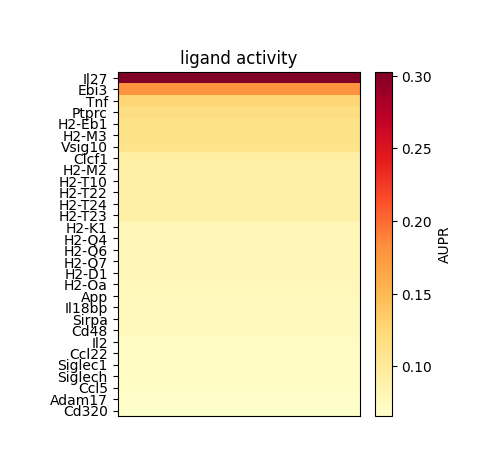

In [20]:
ligands, metrics = zip(*ligand_activities_sorted[:30])
fig, ax = heatmap_1d(
    [e["aupr_corrected"] for e in metrics],
    labels=ligands,
    title="ligand activity",
    cbar_label="AUPR",
    cmap="YlOrRd",
    figsize=(4, 4)
)
ax.invert_yaxis()
plt.show()

19) Prepare the weighted ligand-target data frame for visualization by transforming it into matrix. By default, regulatory potentials lower than the 25th percentile are set to zero for visualization clarity. This cutoff parameter can freely be tuned by the user.

In [21]:
ligand_target_vis, targets, ligands = prepare_ligand_target_visualization(
    predictor,
    active_ligand_target_links,
    cutoff=0.25
)

20) Order the rows to follow the rankings of the ligands, and the columns alphabetically (Figure 3b).

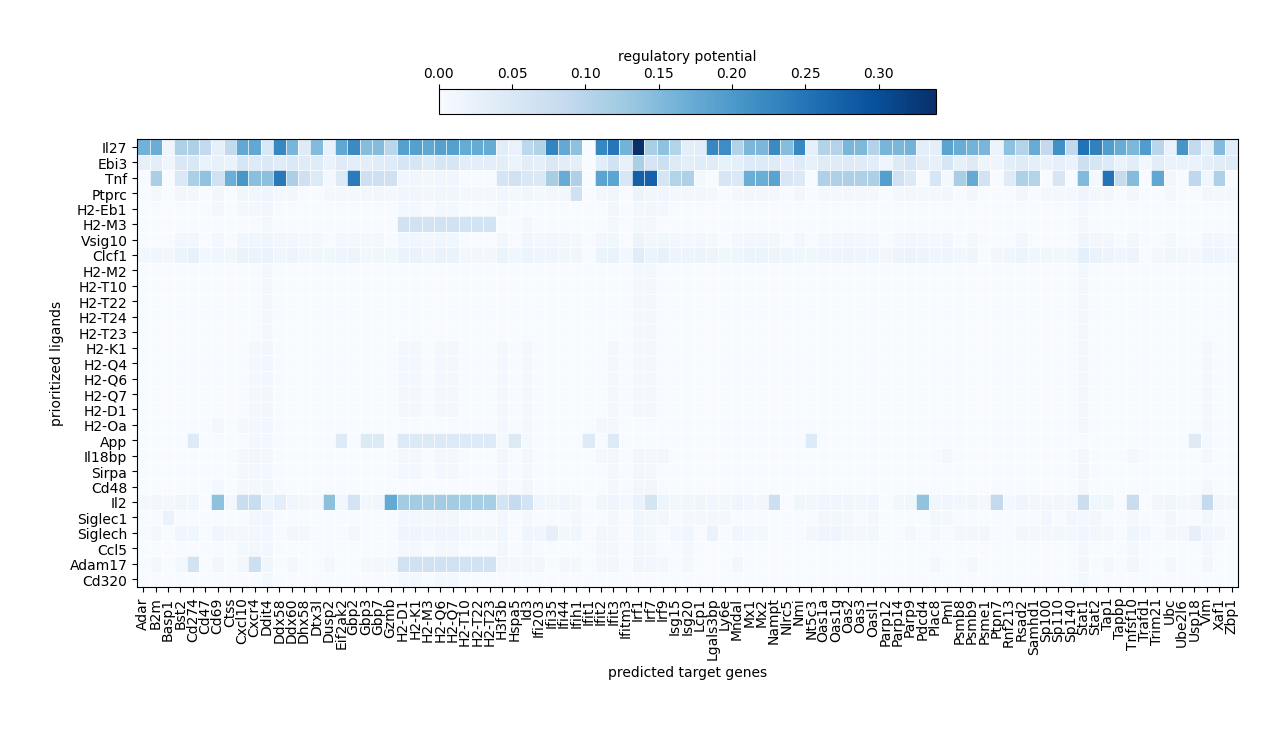

In [22]:
row2id = dict(zip(targets, range(len(targets))))
col2id = dict(zip(ligands, range(len(ligands))))
ligands = [
    x[1] for x in sorted(
        ((best_upstream_ligands.index(e), e) for e in ligands),
        key=lambda x : x[0],
        reverse=True
    )
]
targets.sort()
ligand_target_vis = subset_matrix(
    ligand_target_vis,
    rows=[row2id[e] for e in targets],
    cols=[col2id[e] for e in ligands]
)
fig, ax = heatmap_2d(
    ligand_target_vis.transpose(),
    xlabels=targets,
    ylabels=ligands,
    xtitle="predicted target genes",
    ytitle="prioritized ligands",
    cbar_label="regulatory potential",
    cmap="Blues",
    figsize=(12, 6)
)
plt.show()

21) Create a heatmap for ligand-receptor interactions (Figure 3c).

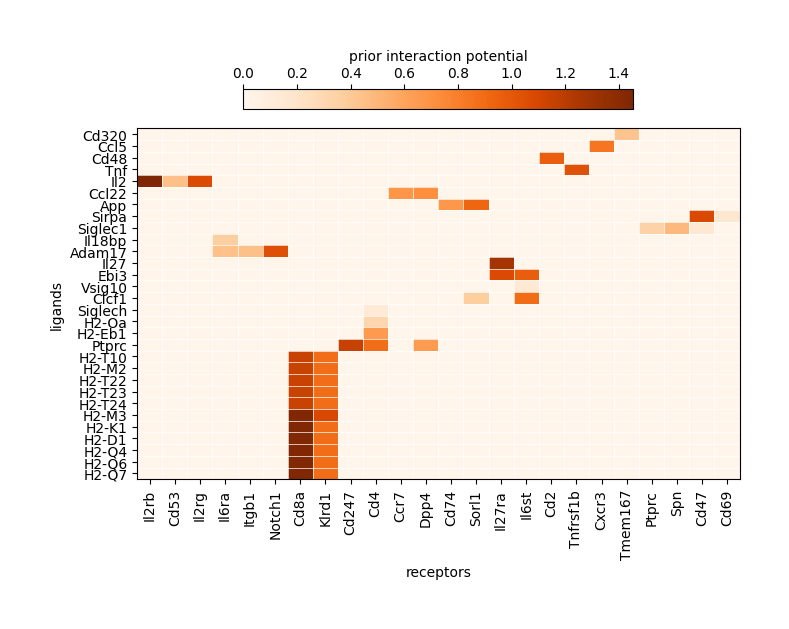

In [23]:
ligand_receptor_links = get_weighted_ligand_receptor_links(
    best_upstream_ligands,
    expressed_receptors,
    lr_network,
    lr_sig
)
mat, ligands, receptors = prepare_ligand_receptor_visualization(ligand_receptor_links)
fig, ax = heatmap_2d(
    mat,
    xlabels=receptors,
    ylabels=ligands,
    xtitle="receptors",
    ytitle="ligands",
    cbar_label="prior interaction potential",
    cmap="Oranges",
    figsize=(7, 5)
)
plt.show()

22) For each cell type, compute the log-fold change of the top-ranked ligands between treatment conditions.

In [24]:
lfcs = combine_by_key(*(
    get_lfc_celltype(
        ann,
        celltype,
        "aggregate",
        condition_oi="LCMV",
        condition_ref="SS",
        layer="data",
        features=best_upstream_ligands
    )
    for celltype in sender_celltypes
))
# sort by ligand activity
ligands, vals = zip(*(
    (ligand, metrics_vals[1])
    for ligand, metrics_vals in
    sorted(
        combine_dicts(ligand_activities, lfcs).items(),
        key=lambda x : x[1][0]["aupr_corrected"],
        reverse=True
    )
))

23) Create the heatmap (Figure 3d).

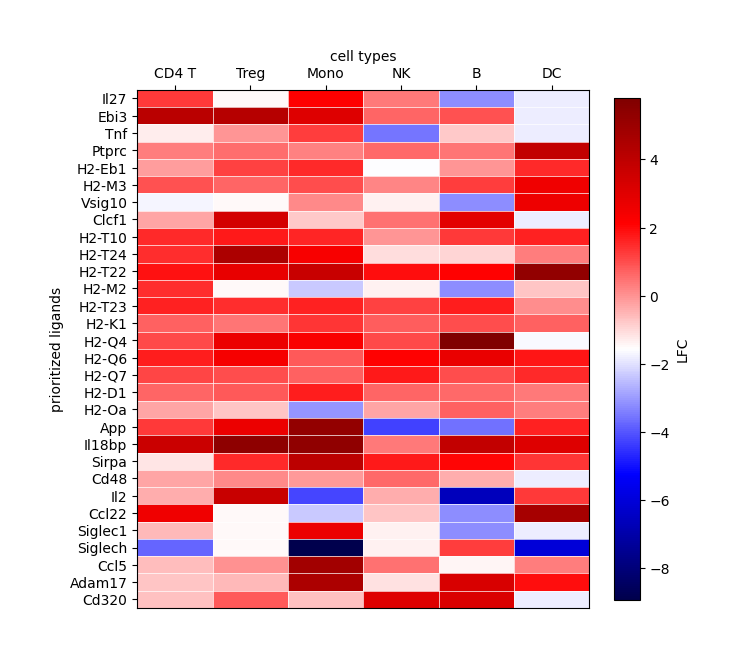

In [25]:
fig, ax = heatmap_2d(
    np.vstack(vals),
    xlabels=sender_celltypes,
    ylabels=ligands,
    xtitle="cell types",
    ytitle="prioritized ligands",
    cbar_label="LFC",
    cbar_position="right",
    cbar_orientation="vertical",
    cmap="seismic",
    figsize=(6, 6)
)
ax.invert_yaxis()
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top') 
plt.show()

24) Create a dot plot showing the average expression of ligands per cell type, as well as the percentage of cells from the cell type expressing the ligands (Figure 3e).

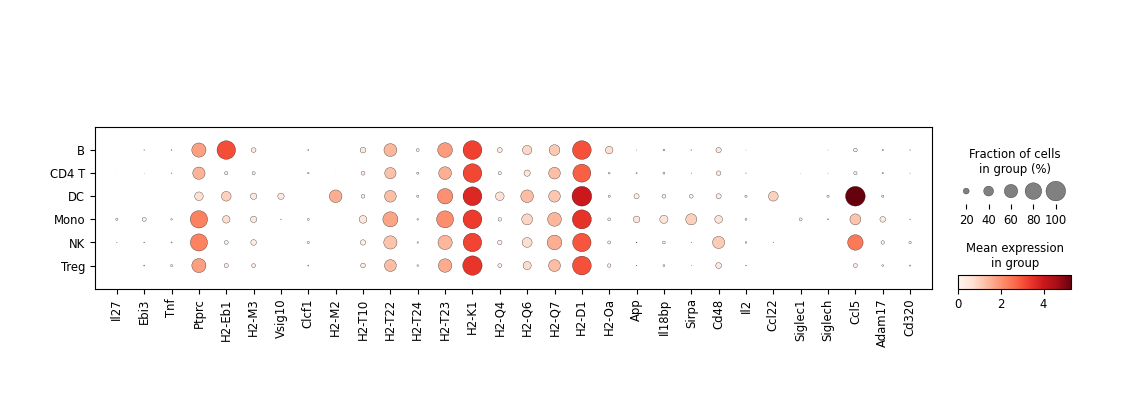

In [26]:
sub_ann = subset_ann(
    ann,
    val=sender_celltypes,
    val_col="celltype",
    layers=["data"]
)
sub_ann.var = ann.var
sub_ann.X = sub_ann.layers["data"]
sc.pl.dotplot(
    sub_ann,
    var_names=best_upstream_ligands,
    groupby="celltype",
    gene_symbols="gene"
)

25) To create a ligand-target chord diagram, assign each ligand to a specific cell type.

In [27]:
# the best upstream ligands are not necessarily present in the AnnData object
ligand_type_indication = assign_ligands_to_celltype(ann, sorted(set(best_upstream_ligands).intersection(ann.var_names)))
ligand_type_indication

,ligand_type,ligand
0,B,H2-Oa
1,B,H2-M3
2,B,H2-T24
3,B,Cd320
4,B,H2-Eb1
5,CD8 T,Clcf1
6,DC,H2-T23
7,DC,H2-Q4
8,DC,Ccl5
9,DC,Ccl22


26) Using the weighted ligand-target data frame from Step 16, group target genes and filter out the lowest 40% of the regulatory potentials. In this case, there is only one grouping of target genes (DE genes after LCMV infection), but users can define multiple target gene groups if applicable. In case the resulting chord diagram is still overcrowded, users may adjust the cutoff parameter to filter out even more ligand-target links.

In [28]:
quantile_cutoff = 0.4
active_ligand_target_links = pd.DataFrame(
    active_ligand_target_links,
    columns=("ligand", "target", "weight")
)
df = active_ligand_target_links.merge(ligand_type_indication, how="inner")
cutoff = np.quantile(df["weight"], quantile_cutoff)
circos_df = df[df["weight"] > cutoff]
circos_ligands = set(circos_df["ligand"])
circos_targets = set(circos_df["target"])
circos_links = df[
    [
        l in circos_ligands and t in circos_targets
        for l, t in zip(df["ligand"], df["target"])
    ]
]

27) Assign colors to cell types and target gene groups. Then, prepare the data frame for visualization: the function assigns colors to ligands and targets and calculates gaps between sectors of the chord diagram.

In [29]:
colors = {
    "General": "#377EB8",
    "NK": "#4DAF4A",
    "B": "#984EA3",
    "Mono": "#FF7F00",
    "DC": "#FFFF33",
    "Treg": "#F781BF",
    "CD8 T": "#E41A1C",
    "target": "#999999"
}

28) Draw the chord diagram (Figure 3g).

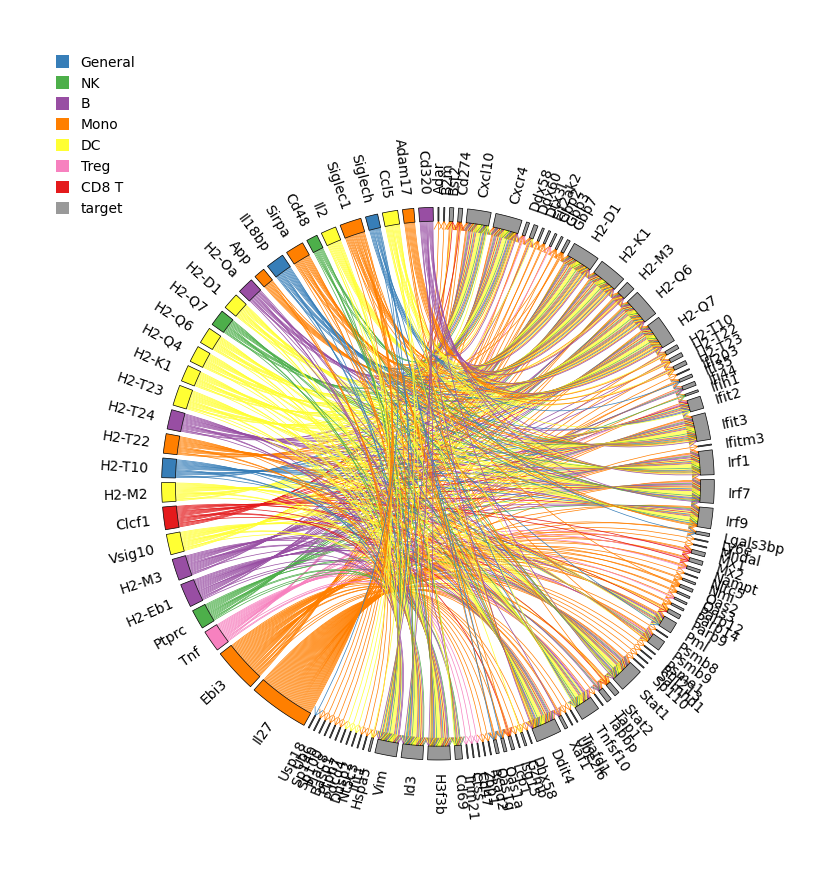

In [30]:
_ = create_ligand_links_circos_plot(
    circos_links,
    colors=colors,
    dest_name="target"
)

29) To create a ligand-receptor chord diagram, we can perform similar steps
as above using the weighted ligand-receptor dataframe instead. 

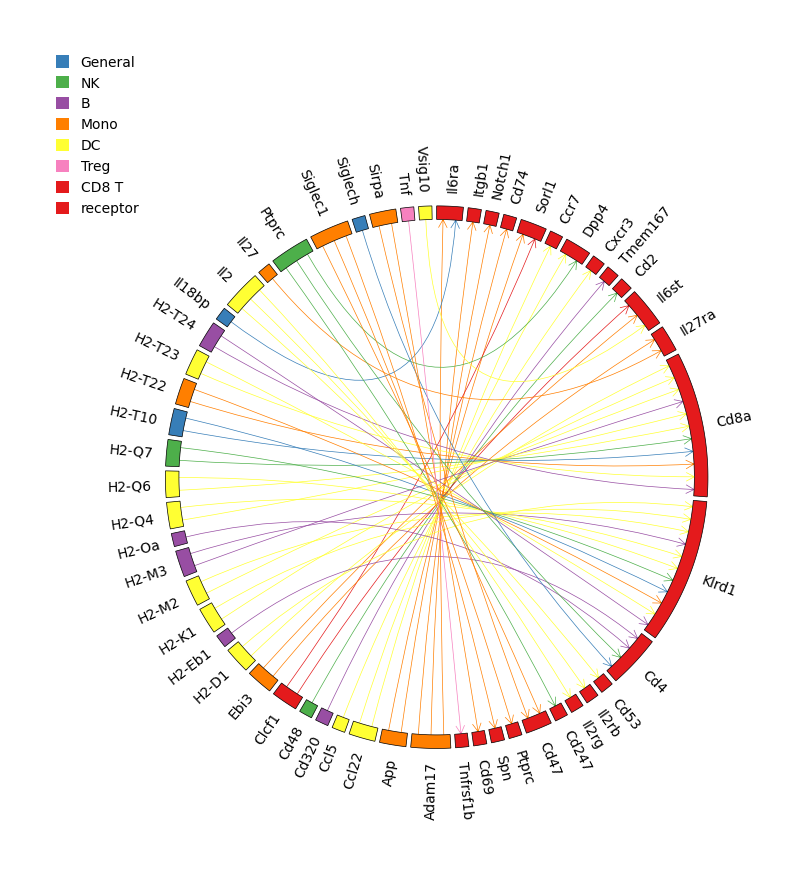

In [31]:
_ = create_ligand_links_circos_plot(
    pd.DataFrame(
        ligand_receptor_links._mapping,
        columns=("ligand", "receptor", "weight")
    ).merge(ligand_type_indication, how="inner"),
    colors={
        "General": "#377EB8",
        "NK": "#4DAF4A",
        "B": "#984EA3",
        "Mono": "#FF7F00",
        "DC": "#FFFF33",
        "Treg": "#F781BF",
        "CD8 T": "#E41A1C",
        "receptor": "#E41A1C"
    },
    dest_name="receptor"
)

30) To create a signaling graph, first download the ligand-transcription factor matrix. Then, extract the most highly weighted paths from the ligand to the target genes of interest. The number of regulators that are extracted can be adjusted using top_n_regulators. By setting minmax_scaling = TRUE, we perform min-max scaling to make the weights between the signaling and gene regulatory network more comparable. Additionally, it is possible to check which data sources support the inferred pathway by using the function infer_supporting_datasources. This would require separate signaling and gene regulatory networks as input.

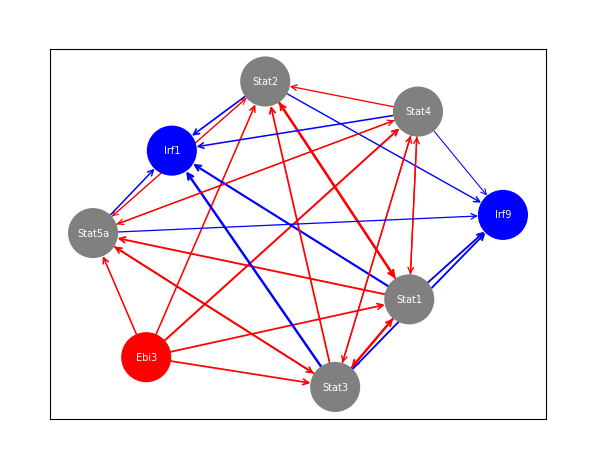

In [33]:
model_path = os.path.normpath("./tutorial_files")
if not os.path.exists(model_path):
    os.makedirs(model_path)
for filename in (
    ["ltf_matrix_mouse.pkl"]
):
    file_path = os.path.join(model_path, filename)
    if not os.path.exists(file_path):
        res = requests.get(f"https://zenodo.org/records/15131577/files/{filename}")
        with open(file_path, "wb") as file:
            file.write(res.content)
with open("./tutorial_files/ltf_matrix_mouse.pkl", "rb") as file:
    ltf_matrix = pickle.loads(file.read())
row_names = ltf_matrix["row_names"]
col_names = ltf_matrix["col_names"]
ltf_matrix = ltf_matrix["mat"]
ligands_oi = ["Ebi3"]
targets_oi = ["Irf1", "Irf9"]
lr_sig_df = pd.DataFrame(model["lr_sig"]._mapping, columns=["from", "to", "weight"])
gr_df = pd.DataFrame(model["gr"]._mapping, columns=["from", "to", "weight"])
tf_signaling, tf_regulatory = get_ligand_signaling_path(
    ltf_matrix,
    ligands_oi,
    targets_oi,
    row_names,
    col_names,
    lr_sig_df,
    gr_df,
    top_n_regulators=4,
    minmax_scaling=True
)
tf_signaling, tf_regulatory = get_ligand_signaling_path(
    ltf_matrix,
    ligands_oi,
    targets_oi,
    row_names,
    col_names,
    lr_sig_df,
    gr_df,
    top_n_regulators=4,
    minmax_scaling=True
)
visualize_ligand_signaling_graph(
    tf_signaling,
    tf_regulatory,
    ligands_oi,
    targets_oi
)

## Prioritization of ligand-receptor pairs

This section is only applicable for the sender-focused approach. Whereas Step 12 prioritizes ligands only on the basis of their activity through target gene expression, this section incorporates relative expression and differential expression to further prioritize LR pairs associated with specific sender and receiver cell types. 

31) Filter the ligand-receptor network to only contain expressed interactions.

In [ ]:
lr_network_filtered = lr_network.subset_sep(expressed_ligands, expressed_receptors)

32) Calculate the values required for prioritization, including DE between cell types, average expression, and DE between conditions. To use the wrapper function, follow option A. To calculate these values step-by-step, follow option B.

A. Using the wrapper function.

(i) Run the wrapper function. In case of steady-state datasets, use scenario="one_condition" and do not provide anything to the condition_ arguments.

In [ ]:
info_tables = generate_info_tables(
    ann,
    "celltype",
    sender_celltypes,
    ["CD8 T"],
    lr_network_filtered,
    "aggregate",
    "LCMV",
    "SS",
    case_control=True
)

(ii) Assign the output of the wrapper function to variables.

In [ ]:
sender_receiver_info = info_tables["sender_receiver_info"]
sender_receiver_de = info_tables["sender_receiver_de"]
lr_condition_de = info_tables["lr_condition_de"]

(B) Running step-by-step calculations.

(i) Calculate DE between cell types within the condition of interest. The min.pct, logfc.threshold, and return.thresh parameters are required for the function to return p-values for all features and cell types.